In [1]:
%%bash
pip install --upgrade pymupdf 
pip install sentence-transformers
pip install spacy
python -m spacy download en_core_web_lg

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━���━━━━━━━━ 400.7/400.7 MB 156.0 MB/s eta 0:00:0000:0100:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_lg')


In [3]:
import re
import requests
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import fitz  # PyMuPDF
from io import BytesIO

import spacy
import gensim
import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.stats import spearmanr


/home/rfu_smith_edu/.conda/envs/txt2onto2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
nlp = spacy.load("en_core_web_lg")

In [5]:
def extract_pdf_text_with_pymupdf(url):
    # This function downloads a pdf from a URL and returns the contents
    response = requests.get(url)
    doc = fitz.open(stream=BytesIO(response.content), filetype="pdf")
    
    text = ""
    for page in doc:
        text += page.get_text()
    
    return text

In [6]:
def clean_and_fix_pdf_text(text):
    # This function cleans up breed standard text. 
    
    
    # Specific to dog breed documents:
    
    # Remove footer lines like "FCI-St. N° 122 / 30.09.2022"
    text = re.sub(r"FCI-St\.\s+N°\s+\d+\s*/\s*\d{2}\.\d{2}\.\d{4}", "", text)
    
    
    # Generally useful:
    
    # Replace line breaks and tabs
    text = re.sub(r'[\r\n\t]+', ' ', text)
    text = re.sub(r' {2,}', ' ', text).strip()
    text = text.lower()
    
    # Remove all punctuation (preserve spaces and alphanumerics)
    text = re.sub(r'[^\w\s]', '', text)
    
    return text

In [7]:
# Retrieve text from a list of URLs, clean the text, and store the cleaned text in a list called docs
docs = []
labels = ["Labrador", "Newfoundland", "Golden Retriever"]
for url in ["https://www.fci.be/en//Nomenclature/Standards/122g08-en.pdf", "https://www.fci.be/en//Nomenclature/Standards/050g02-en.pdf",  "https://www.fci.be/en//Nomenclature/Standards/111g08-en.pdf"]:
    response = requests.get(url)
    
    # Wrap the response content in a BytesIO stream
    pdf_stream = BytesIO(response.content)
    cleaned_text = extract_pdf_text_with_pymupdf(url)
    cleaned_text = clean_and_fix_pdf_text(cleaned_text)
    docs.append(cleaned_text)

In [8]:
def train_tree_from_pdfs(documents, labels, show_tree=True, max_depth=3):

    # load open‑source model by its SBERT name
    model = SentenceTransformer('all-MiniLM-L6-v2')
    embeddings = model.encode(docs)

    if labels is None:
        labels = list(range(len(docs)))

    clf = DecisionTreeClassifier(max_depth=max_depth)
    clf.fit(embeddings, labels)

    if show_tree:
        plt.figure(figsize=(12,8))
        from sklearn import tree
        tree.plot_tree(clf, filled=True)
        plt.show()

    return clf, embeddings

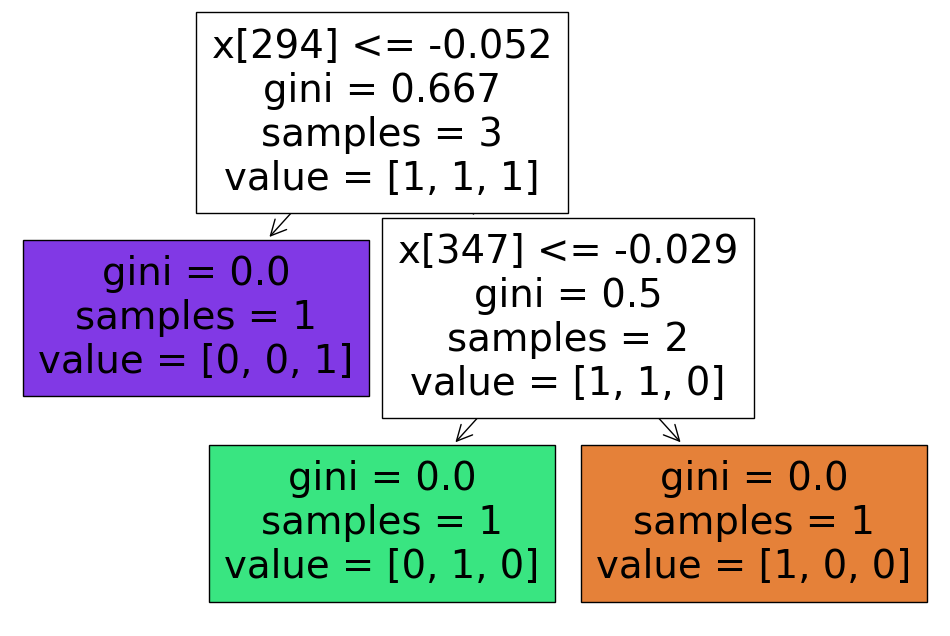

In [9]:
clf, embeddings = train_tree_from_pdfs(docs, labels)

In [10]:
vectorizer = TfidfVectorizer(stop_words='english')
tfidf_matrix = vectorizer.fit_transform(docs)


# Pick an embedding feature to investigate
feature_vals = embeddings[:, 46]  # or 350 etc.

# Spearman correlation between each word’s tf-idf and that embedding feature
correlations = [
    spearmanr(tfidf_matrix[:, i].toarray().flatten(), feature_vals)[0]
    for i in range(tfidf_matrix.shape[1])
]

# Get the corresponding word names
feature_names = np.array(vectorizer.get_feature_names_out())
top_correlated_words = feature_names[np.argsort(correlations)[-10:]]
top_indices = np.argsort(np.abs(correlations))[-10:]
for i in reversed(top_indices):
    print(f"{feature_names[i]}: {correlations[i]:.3f}")

dog: 1.000
regarded: -1.000
set: -1.000
head: 1.000
seriousness: -1.000
health: -1.000
healthy: -1.000
section: -1.000
secretariat: -1.000
scrotum: -1.000


In [11]:
def interpret_split_feature(feature_index, embeddings, docs, vectorizer=None, top_k=10):
    if vectorizer is None:
        from sklearn.feature_extraction.text import TfidfVectorizer
        vectorizer = TfidfVectorizer(stop_words='english')
        tfidf_matrix = vectorizer.fit_transform(docs)

    feature_vals = embeddings[:, feature_index]
    correlations = [
        spearmanr(tfidf_matrix[:, i].toarray().flatten(), feature_vals)[0]
        for i in range(tfidf_matrix.shape[1])
    ]

    feature_names = np.array(vectorizer.get_feature_names_out())
    top_pos_idx = np.argsort(correlations)[-top_k:]
    top_neg_idx = np.argsort(correlations)[:top_k]

    return {
        "feature_index": feature_index,
        "top_positive": [(feature_names[i], correlations[i]) for i in reversed(top_pos_idx)],
        "top_negative": [(feature_names[i], correlations[i]) for i in top_neg_idx],
    }


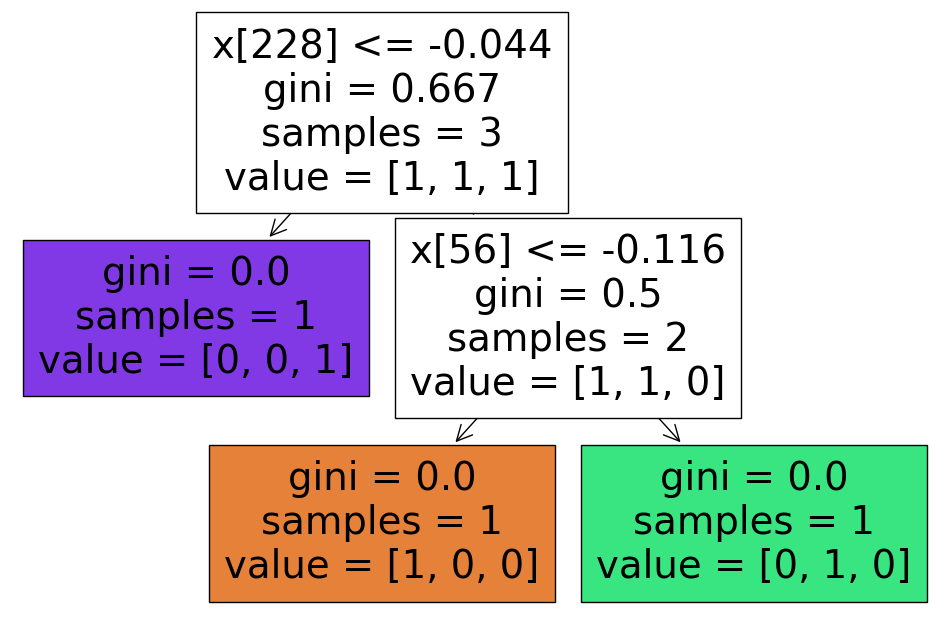

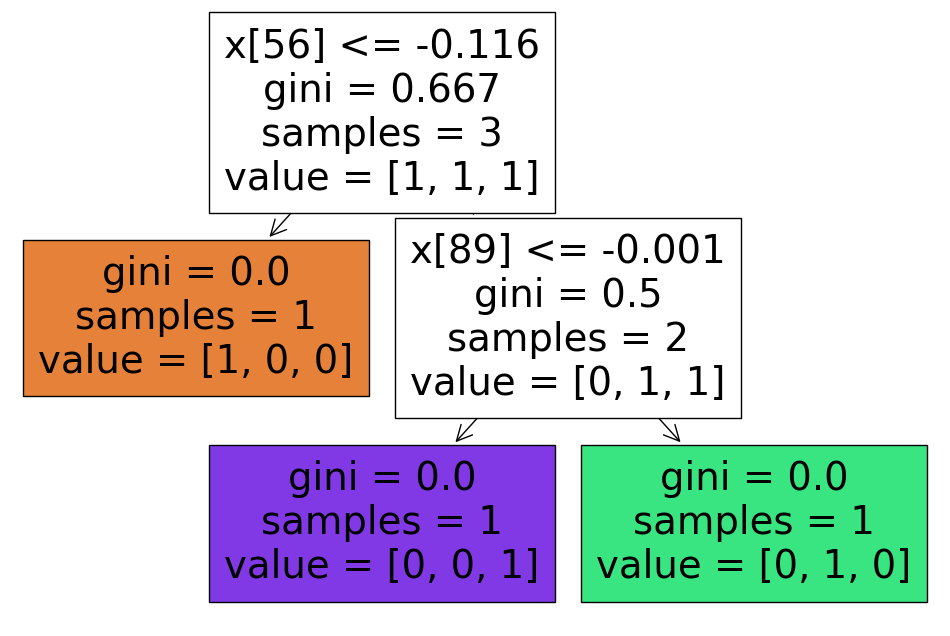

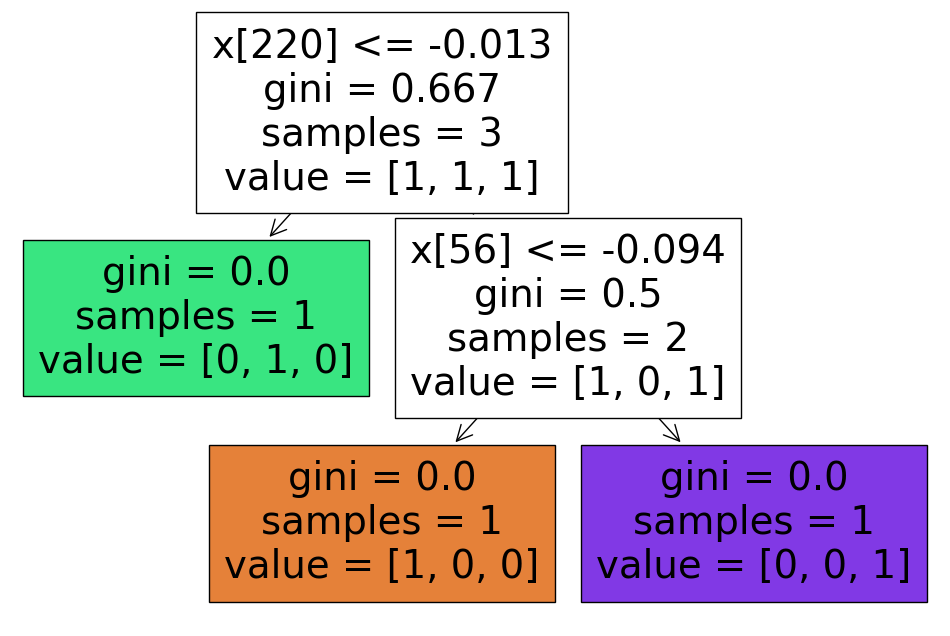

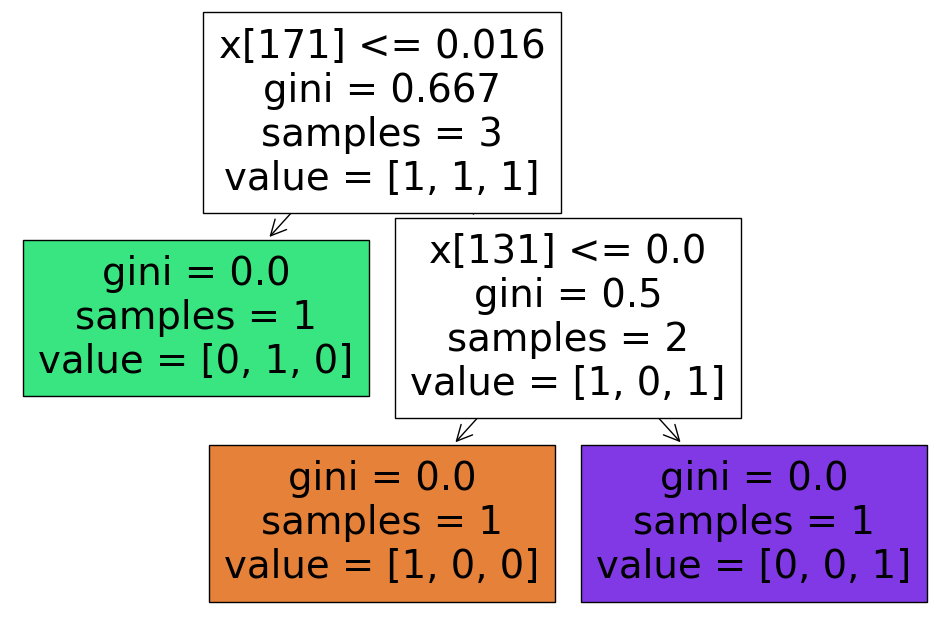

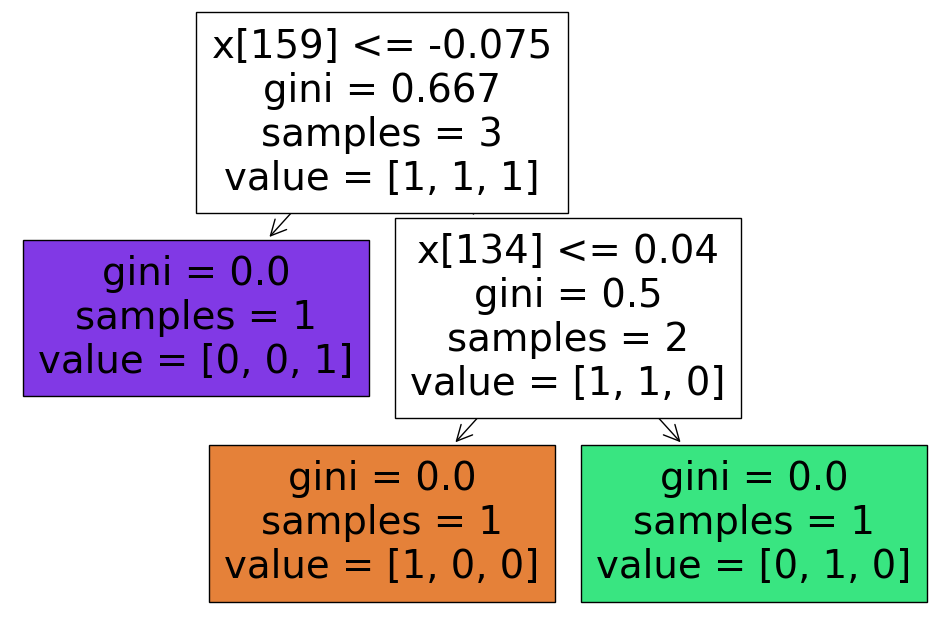

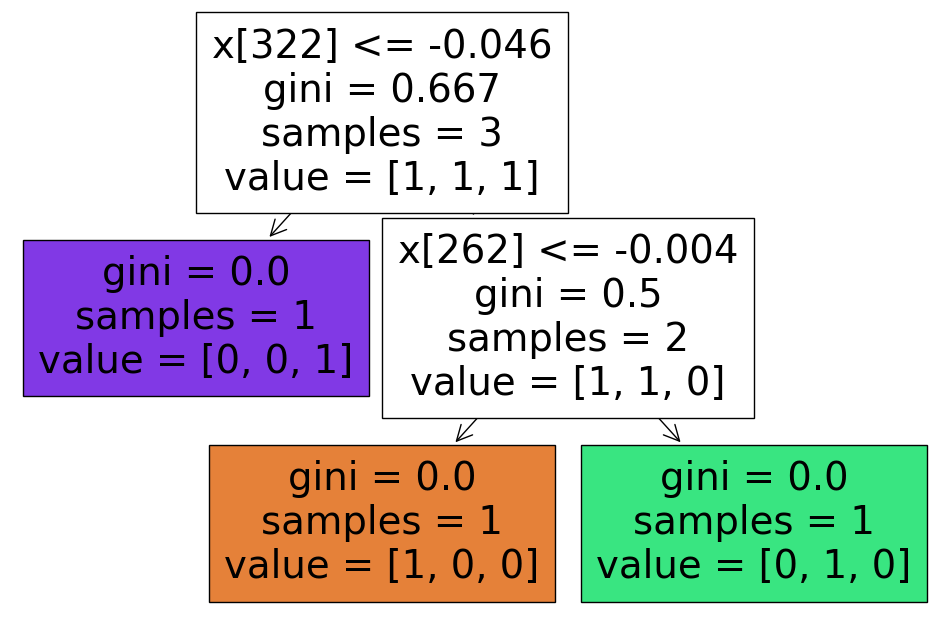

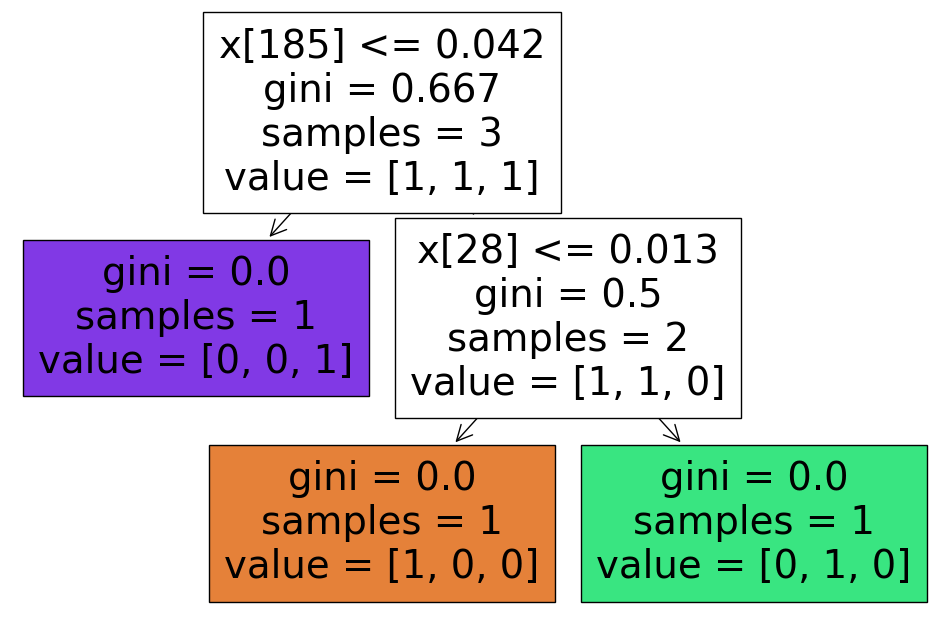

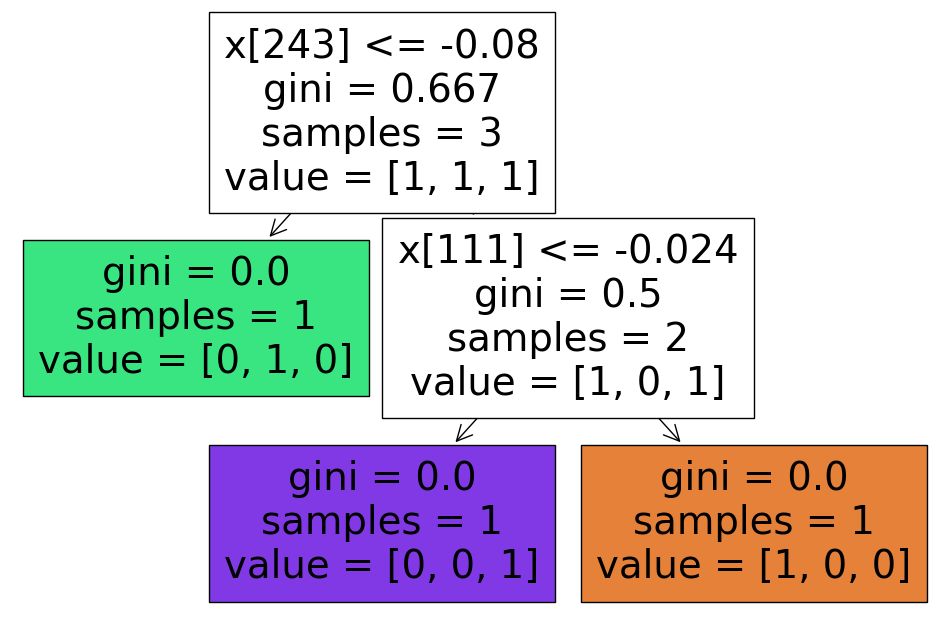

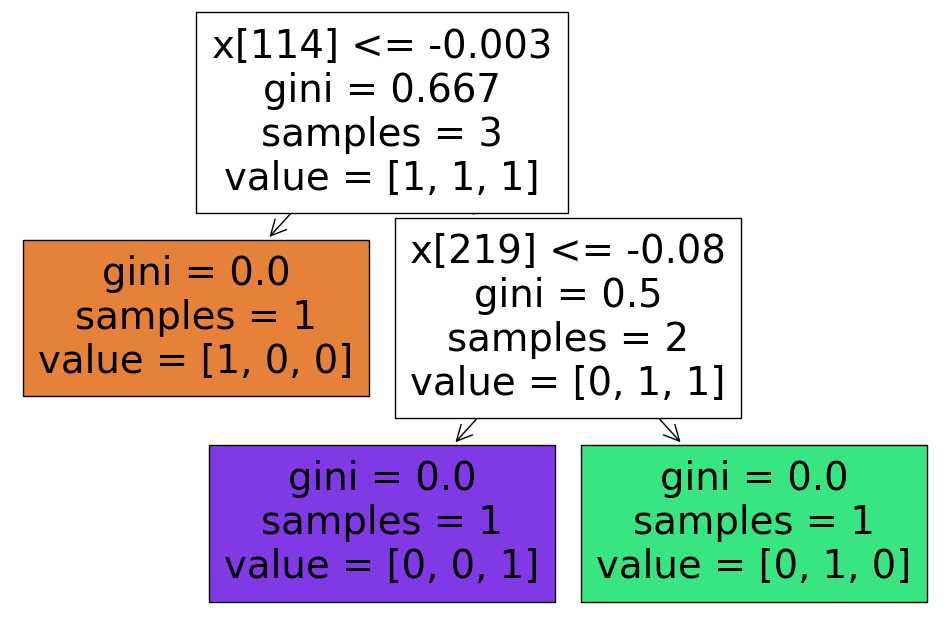

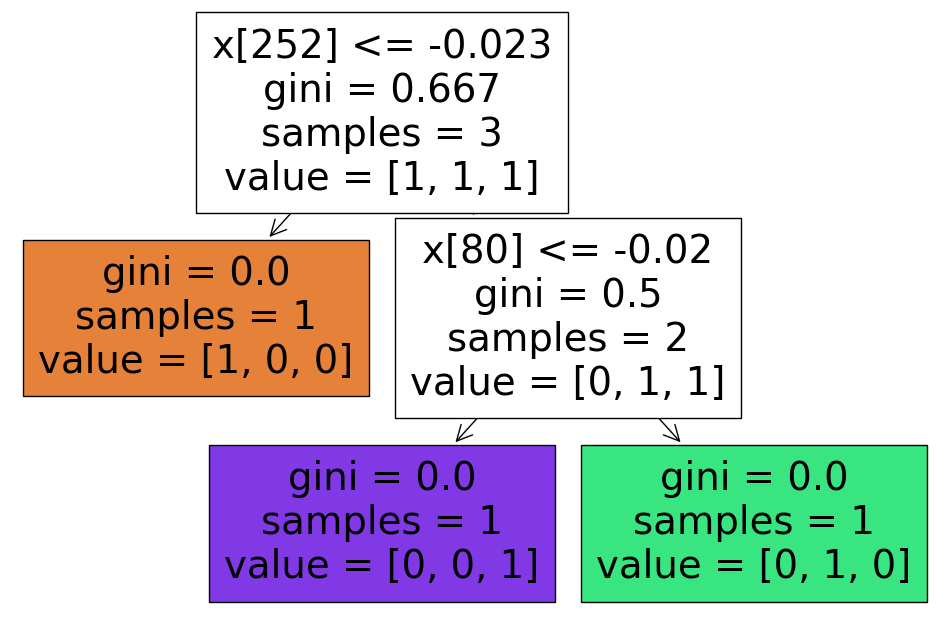

In [12]:
for i in range(10):
    clf, embeddings = train_tree_from_pdfs(docs, labels)

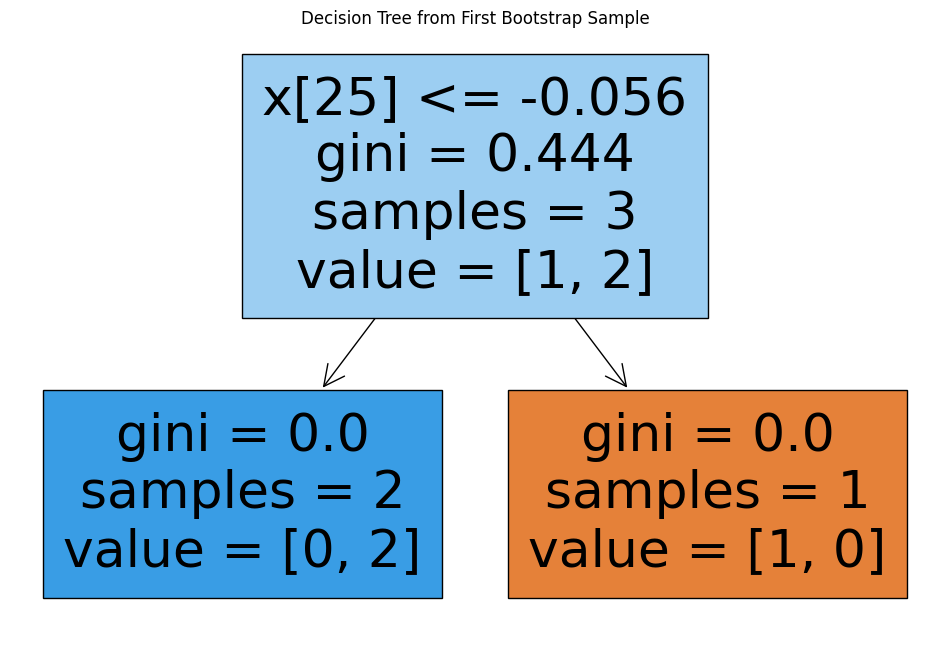

   run  feature class_distribution  \
0    0       25         [1.0, 2.0]   
1    2      300         [2.0, 1.0]   
2    3      284         [1.0, 2.0]   
3    4      314    [1.0, 1.0, 1.0]   
4    4      368    [1.0, 1.0, 0.0]   
5    5      351         [1.0, 2.0]   
6    6      155    [1.0, 1.0, 1.0]   
7    6      146    [1.0, 1.0, 0.0]   
8    7      321         [1.0, 2.0]   
9    8      371         [1.0, 2.0]   

                                                                           top_words  
0  [(yellow, -1.0), (faults, 1.0), (evident, -1.0), (exact, 1.0), (excessive, -1.0)]  
1      [(yellows, -1.0), (en, -1.0), (equals, 1.0), (exact, 1.0), (excellent, -1.0)]  
2           [(yellows, 1.0), (far, 1.0), (fairly, 1.0), (facial, 1.0), (eyes, -1.0)]  
3        [(tip, -1.0), (long, -1.0), (appearance, 1.0), (legs, -1.0), (black, -1.0)]  
4       [(dog, -1.0), (regarded, 1.0), (set, 1.0), (head, -1.0), (seriousness, 1.0)]  
5       [(yellows, 1.0), (en, 1.0), (equals, -1.0), (exact,

In [13]:
# ---- INTERPRET FEATURE WITH WORDS ----
def interpret_feature(docs, embeddings, feature_index, top_k=5):
    vectorizer = TfidfVectorizer(stop_words='english')
    tfidf_matrix = vectorizer.fit_transform(docs)
    feature_vals = embeddings[:, feature_index]
    correlations = [
        spearmanr(tfidf_matrix[:, i].toarray().flatten(), feature_vals)[0]
        for i in range(tfidf_matrix.shape[1])
    ]
    feature_names = np.array(vectorizer.get_feature_names_out())
    top_indices = np.argsort(np.abs(correlations))[-top_k:]
    return [(feature_names[i], correlations[i]) for i in reversed(top_indices)]

# ---- MAIN BOOTSTRAP FUNCTION ----
def analyze_bootstrapped_trees(docs, labels, runs=10, max_depth=2, show_first_tree=True):
    model = SentenceTransformer('all-MiniLM-L6-v2')
    all_results = []

    for run in range(runs):
        indices = [random.randint(0, len(docs) - 1) for _ in range(len(docs))]
        boot_docs = [docs[i] for i in indices]
        boot_labels = [labels[i] for i in indices]
        embeddings = model.encode(boot_docs)

        clf = DecisionTreeClassifier(max_depth=max_depth, random_state=run)
        clf.fit(embeddings, boot_labels)

        if run == 0 and show_first_tree:
            plt.figure(figsize=(12, 8))
            plot_tree(clf, filled=True)
            plt.title("Decision Tree from First Bootstrap Sample")
            plt.show()

        tree_ = clf.tree_
        split_features = tree_.feature
        class_distributions = tree_.value.squeeze(axis=1)

        for node_id, feat in enumerate(split_features):
            if feat == -2:
                continue
            word_corrs = interpret_feature(boot_docs, embeddings, feat, top_k=5)
            all_results.append({
                "run": run,
                "node_id": node_id,
                "feature": feat,
                "class_distribution": class_distributions[node_id].tolist(),
                "top_words": word_corrs,
                "bootstrap_indices": indices
            })

    return pd.DataFrame(all_results)

# ---- EXAMPLE USAGE ----


df = analyze_bootstrapped_trees(docs, labels, runs=10, max_depth=2)
pd.set_option("display.max_colwidth", None)
print(df[["run", "feature", "class_distribution", "top_words"]].head(10))


In [14]:
df.to_csv("split_feature_word_correlations.csv", index=False)

## Trial

In [25]:
def analyze_with_new_doc(new_title):
    docs = [
        "RNA-seq in acute myeloid leukemia (AML) cells with and without knockdown of METTL14",
        "Analysis of gene expression changes in RN2 acute myeloid leukemia (AML) cells at 24hrs and 48hrs after Ddx5 knockdown.",
        new_title
    ]
    labels = ["Human", "Mouse", "Random"]

    model = SentenceTransformer('all-MiniLM-L6-v2')
    embeddings = model.encode(docs)

    clf = DecisionTreeClassifier(max_depth=2)
    clf.fit(embeddings, labels)

    plt.figure(figsize=(8, 4))
    plot_tree(clf, filled=True, feature_names=[f"dim_{i}" for i in range(embeddings.shape[1])])
    plt.title("Human vs Mouse Decision Tree")
    plt.show()

    split_feature_index = clf.tree_.feature[0]
    print(f"Split feature index: {split_feature_index}")

    vectorizer = TfidfVectorizer(stop_words='english')
    tfidf_matrix = vectorizer.fit_transform(docs)

    feature_vals = embeddings[:, split_feature_index]
    correlations = [
        spearmanr(tfidf_matrix[:, i].toarray().flatten(), feature_vals)[0]
        for i in range(tfidf_matrix.shape[1])
    ]

    feature_names = np.array(vectorizer.get_feature_names_out())
    top_pos_idx = np.argsort(correlations)[-5:]
    top_neg_idx = np.argsort(correlations)[:5]

    print("\nTop positive words for split feature:")
    for i in reversed(top_pos_idx):
        print(f"{feature_names[i]}: {correlations[i]:.3f}")

    print("\nTop negative words for split feature:")
    for i in top_neg_idx:
        print(f"{feature_names[i]}: {correlations[i]:.3f}")

    # print embeddings

In [19]:
import random
import pandas as pd

In [59]:
GREIN_data = pd.read_csv("../demo/GREIN_data.csv")
GREIN_data = GREIN_data['GEO accession']

random_value = random.choice(GREIN_data.tolist())
random_value

'GSE90729'

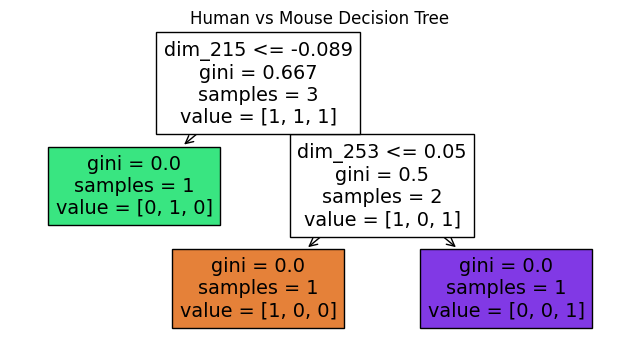

Split feature index: 215

Top positive words for split feature:
human: 0.866
abundant: 0.866
repression: 0.866
pumilio: 0.866
proteins: 0.866

Top negative words for split feature:
24hrs: -0.866
48hrs: -0.866
rn2: -0.866
analysis: -0.866
changes: -0.866


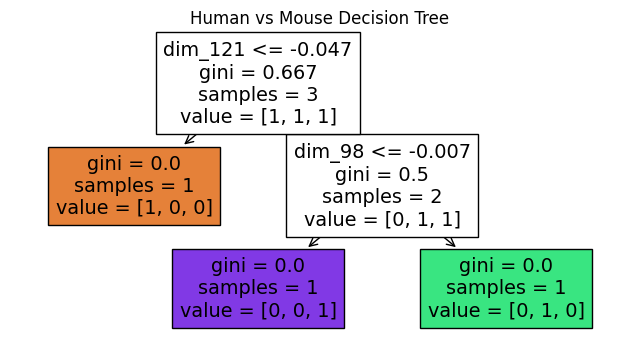

Split feature index: 121

Top positive words for split feature:
yap: 0.866
hippo: 0.866
tumor: 0.866
pathway: 0.866
proliferation: 0.866

Top negative words for split feature:
leukemia: -1.000
acute: -1.000
aml: -1.000
cells: -1.000
myeloid: -1.000


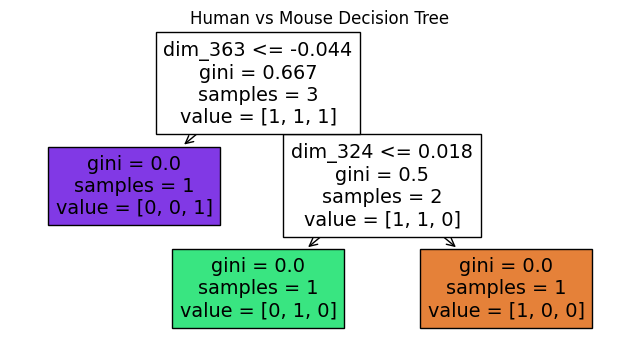

Split feature index: 363

Top positive words for split feature:
24hrs: 0.866
analysis: 0.866
48hrs: 0.866
rn2: 0.866
gene: 0.866

Top negative words for split feature:
seq: -1.000
rna: -1.000
performed: -0.866
sarcoma: -0.866
blocks: -0.866


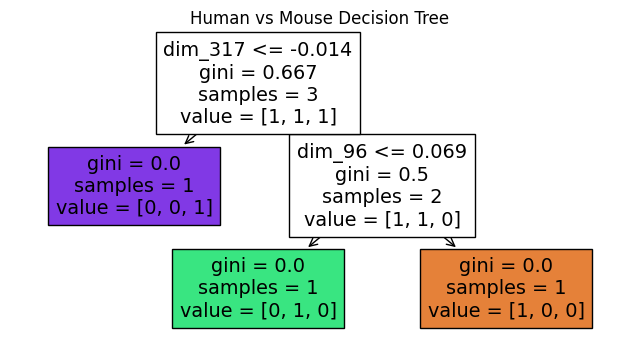

Split feature index: 317

Top positive words for split feature:
knockdown: 1.000
acute: 1.000
myeloid: 1.000
aml: 1.000
cells: 1.000

Top negative words for split feature:
hnscc: -0.866
responses: -0.866
resident: -0.866
memory: -0.866
magnitude: -0.866


In [66]:
GSE79804_human = "A conserved abundant cytoplasmic long noncoding RNA modulates repression of mRNAs by Pumilio proteins in human cells"
analyze_with_new_doc(GSE79804_human)

GSE80372_human = "A splicing switch of TEAD4 regulates Hippo-YAP signaling pathway to inhibit tumor proliferation"
analyze_with_new_doc(GSE80372_human)

GSE71120_human = "RNA-seq performed on FFPE sarcoma blocks"
analyze_with_new_doc(GSE71120_human)

GSE90729_human = "Tissue-resident memory features are linked to the magnitude of cytotoxic T cell responses in human lung cancer [HNSCC]"
analyze_with_new_doc(GSE90729_human)

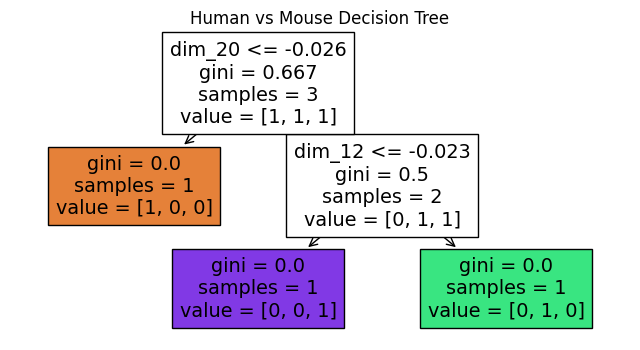

Split feature index: 20

Top positive words for split feature:
24hrs: 0.866
rn2: 0.866
48hrs: 0.866
analysis: 0.866
changes: 0.866

Top negative words for split feature:
seq: -0.866
mettl14: -0.866
rna: -0.866
acute: -0.500
aml: -0.500


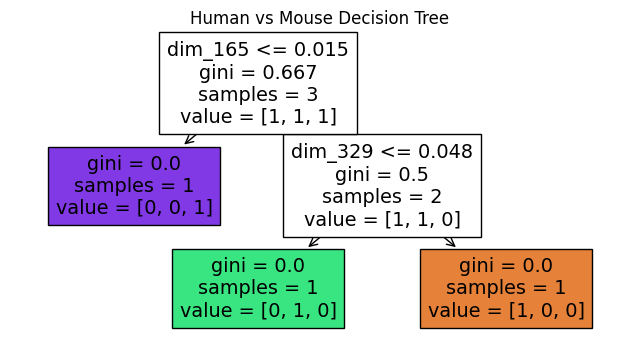

Split feature index: 165

Top positive words for split feature:
gene: 0.866
expression: 0.866
48hrs: 0.866
analysis: 0.866
changes: 0.866

Top negative words for split feature:
specific: -0.866
mouse: -0.866
methylation: -0.866
genome: -0.866
sequence: -0.866


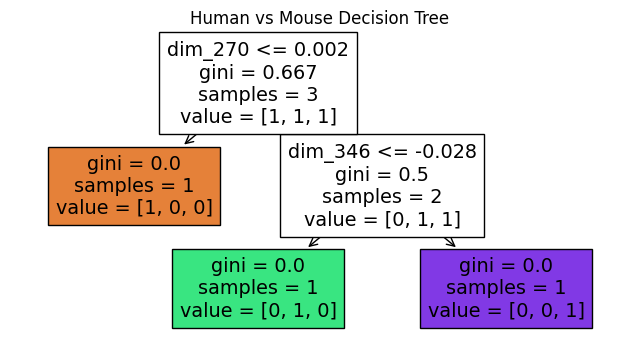

Split feature index: 270

Top positive words for split feature:
expression: 1.000
gene: 1.000
changes: 1.000
caused: 0.866
deficiency: 0.866

Top negative words for split feature:
acute: -1.000
aml: -1.000
cells: -1.000
knockdown: -1.000
leukemia: -1.000


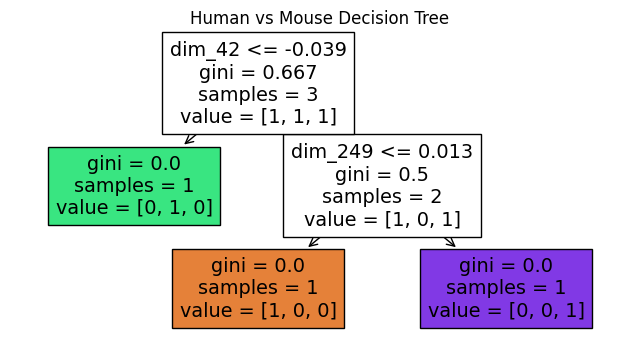

Split feature index: 42

Top positive words for split feature:
seq: 1.000
rna: 1.000
mettl14: 0.866
knockdown: 0.500
aml: 0.500

Top negative words for split feature:
24hrs: -0.866
rn2: -0.866
expression: -0.866
ddx5: -0.866
changes: -0.866


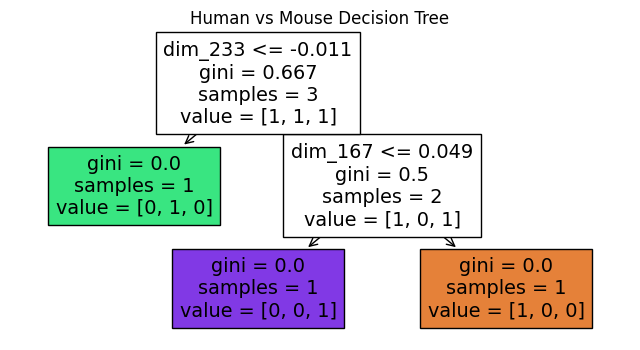

Split feature index: 233

Top positive words for split feature:
wide: 0.866
adipocyte: 0.866
brown: 0.866
regulated: 0.866
differentiation: 0.866

Top negative words for split feature:
24hrs: -0.866
48hrs: -0.866
rn2: -0.866
changes: -0.866
ddx5: -0.866


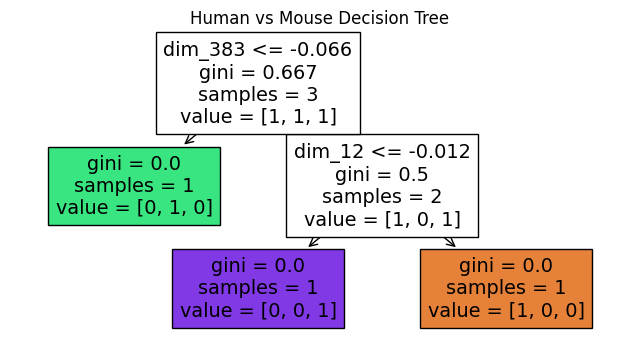

Split feature index: 383

Top positive words for split feature:
cells: 1.000
stem: 0.866
ixen: 0.866
endoderm: 0.866
extraembryonic: 0.866

Top negative words for split feature:
24hrs: -0.866
gene: -0.866
expression: -0.866
ddx5: -0.866
changes: -0.866


In [67]:
GSE80378_mouse = "Identification of genes regulated by REST in developing hearts"
analyze_with_new_doc(GSE80378_mouse)

GSE33468_mouse = "Base-resolution analyses of parent-of-origin and sequence dependent allele specific DNA methylation in the mouse genome (RNA-seq)"
analyze_with_new_doc(GSE33468_mouse)

GSE75775_mouse = "Neuron-specific changes in gene expression caused by NPC1 deficiency"
analyze_with_new_doc(GSE75775_mouse)

GSE81925_mouse = "Cell type-specific regulation by intragenic CpG islands [RNA-seq]"
analyze_with_new_doc(GSE81925_mouse)

GSE74900_mouse = "Transcriptome-wide analysis of gene expression regulated by LSD1 during brown adipocyte differentiation [RNA-seq]"
analyze_with_new_doc(GSE74900_mouse)

# high grade malignant neoplasm
GSE77550_mouse = "OSKM induce extraembryonic endoderm stem (iXEN) cells in parallel to iPS cells"
analyze_with_new_doc(GSE77550_mouse)

In [65]:
all_cancer_predictions = pd.read_csv("../results/cancer_mouse/all_cancer_predictions.csv")
all_cancer_predictions[all_cancer_predictions['ID'] == 'GSE90729'].sort_values('log2(prob/prior)', ascending = False)

,ID,prob,log2(prob/prior),related_words,source


In [ ]:
# add something different to see what split is happening 